In [1]:
import os
os.chdir('/home/linhang/workbench/workbench/Earthquake_predictor/dataset')
os.chdir('/home/linhang/workbench/workbench/Earthquake_predictor/')
from dataset.dataset_utils import *
from model.ES_net_mixer import *
from model import LightingModel
from torch.utils.data import DataLoader
import torch.nn.functional as F
import lightning as L
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import json
from inference_utils import *

In [32]:
dataset_dict = get_dataset(
        data_dir="/home/linhang/workbench/Earthquake_data/",
        window_size=140,
        forecast_horizon=14,
        lape_dim=30,
        geo_percentage=0.3,
        sem_percentage=0.3,
        time_resolution=14,
        earthquake_catalog_window=1400,
        train_percentage=0.8,
        use_area="California (Southern)",
        )

使用指定地区数据：['California (Southern)']
GNSS Data Length: 8472
Earthquake Data Length: 8472


In [33]:
loader_dict = {}
for key, dataset in dataset_dict.items():
    is_train = "train" in key
    loader_dict[key] = DataLoader(
        dataset,
        batch_size=4 if is_train else 4,
        shuffle=is_train,
        collate_fn=dataset.collate_fn,
        num_workers=127
    )

train_loader_key = "train"
val_loader_key = "val"

train_loader = loader_dict.get(train_loader_key)
val_loader = loader_dict.get(val_loader_key)


In [34]:
# model_dir = "/home/linhang/workbench/workbench/Earthquake_predictor/Result/"
# with open("Result/Pretrain_ES_net_mixer_california/Hyperparameters/model_params.json", 'r') as f:
#     model_par = json.load(f)
# model = LightingModel(model = ES_net_mixer, lr = None, max_epoch=None,loss_fns=None,**model_par).to("cuda:0")
# model.initial_model("Result/Pretrain_ES_net_mixer_california/checkpoints/Val-epoch=01-val_loss=0.47.ckpt").to("cuda:2")
# model.eval()
model = LightingModel.load_from_checkpoint("/home/linhang/workbench/workbench/Earthquake_predictor/Result/Pretrain/Pretrain_ES_net_mixer_onlyhappen/checkpoints/Val-epoch=18-TPR=0.06.ckpt",map_location=torch.device("cuda:2"))
def count_model_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
print("count_model_parameters:",count_model_parameters(model.model))
model.eval()

FileNotFoundError: [Errno 2] No such file or directory: '/home/linhang/workbench/workbench/Earthquake_predictor/Result/Pretrain/Pretrain_ES_net_mixer_onlyhappen/checkpoints/Val-epoch=18-TPR=0.06.ckpt'

In [ ]:
use_loader = val_loader

In [ ]:
sample_batch = next(iter(use_loader))

with torch.no_grad():
    predictions = model.predict_step(sample_batch, 0)


In [ ]:
earthquake_history_topk,earthquake_future_topk,energy_predict,topk_index = find_activate_area(sample_batch['log_energy_history'][0],predictions['log_energy_future'][0],predictions['energy_predict'][0],9)

In [ ]:
earthquake_location_topk = np.round(denormalize_locations(predictions['earthquake_location'][0][topk_index]).detach().cpu().numpy(),2)

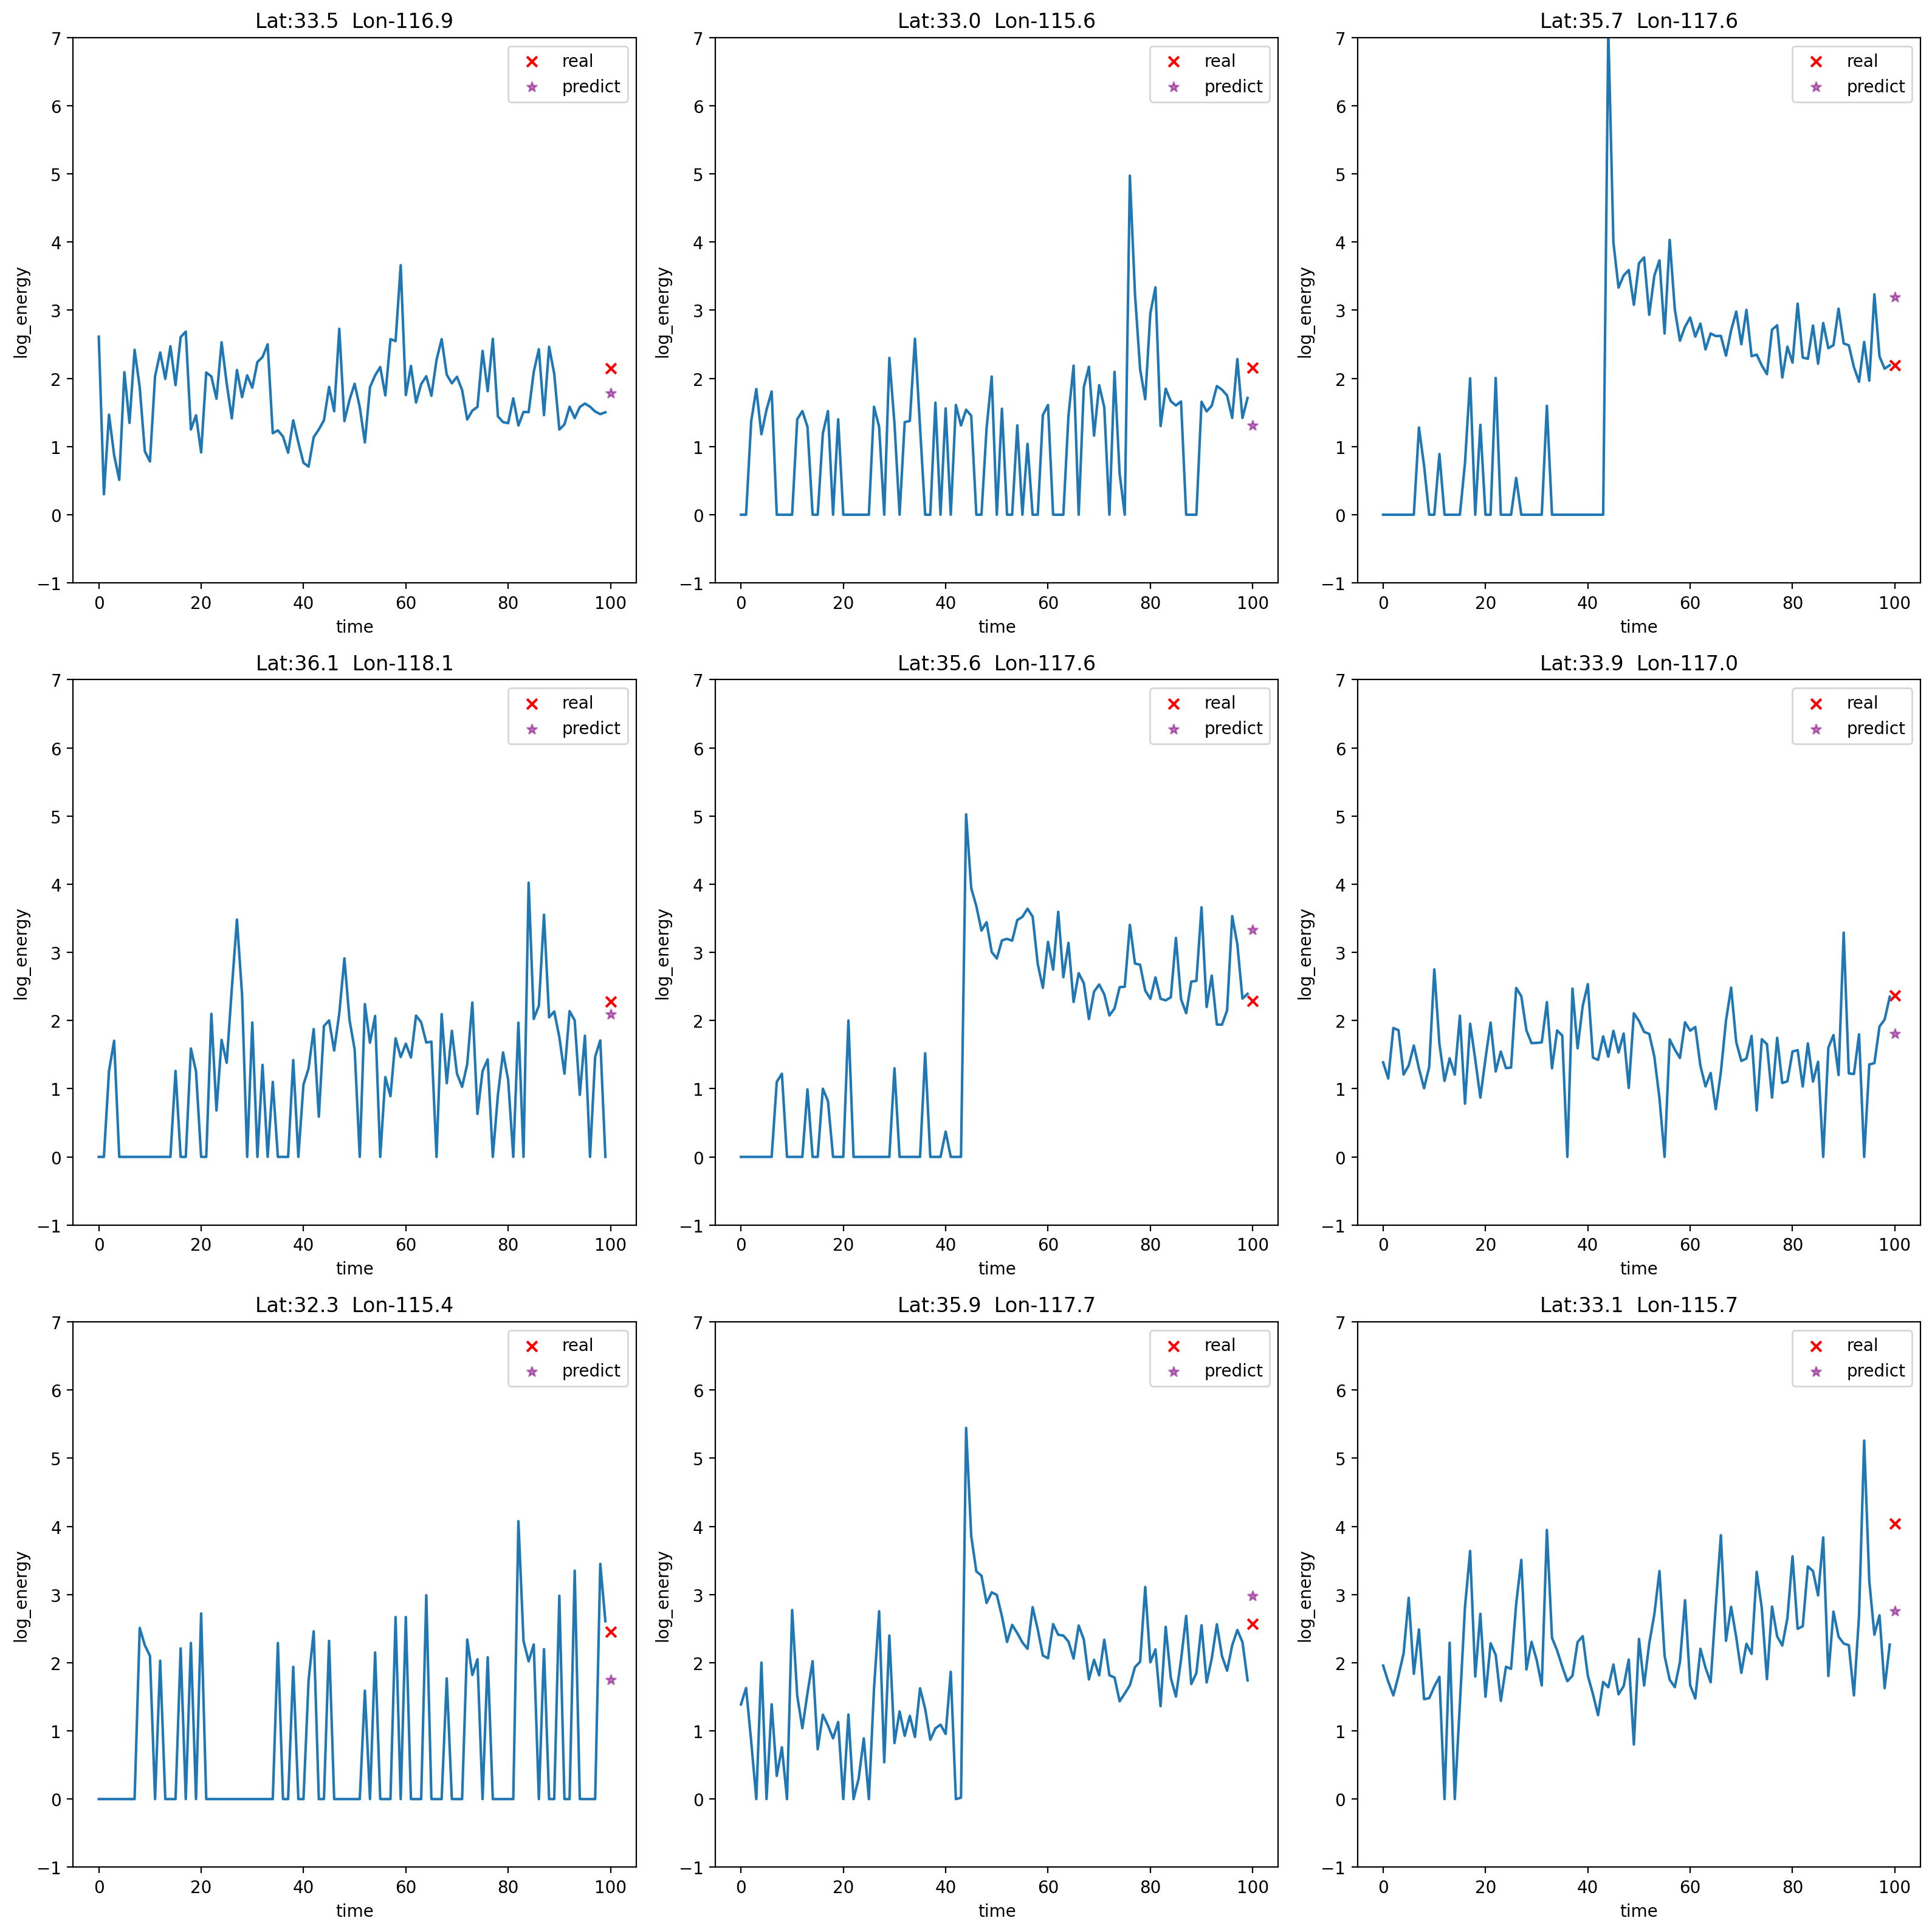

In [ ]:
plt.figure(figsize=(16,16),dpi=200)
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.plot(range(len(earthquake_history_topk[:,i])),earthquake_history_topk[:,i])
    plt.scatter(range(len(earthquake_history_topk[:,i]),len(earthquake_history_topk[:,i])+len(earthquake_future_topk[:,i])),earthquake_future_topk[:,i],c='r',marker='x',label='real')
    plt.scatter(range(len(earthquake_history_topk[:,i]),len(earthquake_history_topk[:,i])+len(energy_predict[:,i])),energy_predict[:,i],c='purple',marker='*',label='predict',alpha=0.5)
    plt.title('Lat:'+str(earthquake_location_topk[i][0])+'  Lon'+str(earthquake_location_topk[i][1]))
    plt.legend()
    plt.xlabel('time')
    plt.ylabel('log_energy')
    plt.ylim(-1,7)
plt.tight_layout()
plt.show()

In [ ]:
energy_predict_all = []
earthquake_future_all = []
energy_history_all = []
earthquake_happen_all = []
with torch.no_grad():
    for batch in use_loader:
        predictions = model.predict_step(batch, 0)
        energy_predict_all.append(predictions['energy_predict'])
        earthquake_future_all.append(predictions['log_energy_future'])
        energy_history_all.append(batch['log_energy_history'])
        earthquake_happen_all.append(batch['earthquake_happen'])
energy_predict_all = torch.cat(energy_predict_all)
earthquake_future_all = torch.cat(earthquake_future_all)
energy_history_all = torch.cat(energy_history_all)
earthquake_happen_all = torch.cat(earthquake_happen_all)


TPR (Recall): 0.00
TNR (Specificity): 1.00
Precision: 0.00
Accuracy: 0.99
Error: 0.01
FPR: 0.00
Aggregative Score: 0.33


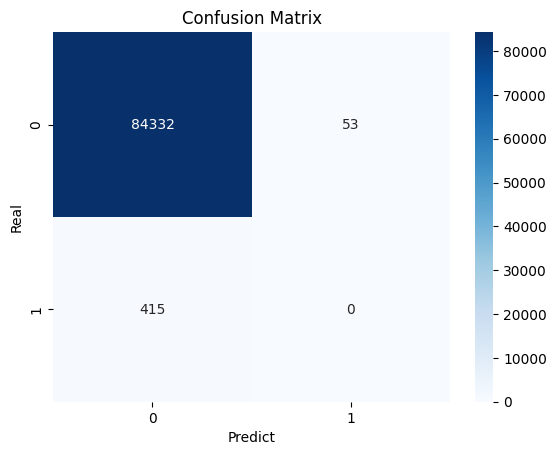

In [ ]:
energy_predict,earthquake_target = plot_confusion_matrix(energy_predict_all,earthquake_future_all,threshold=3.29)

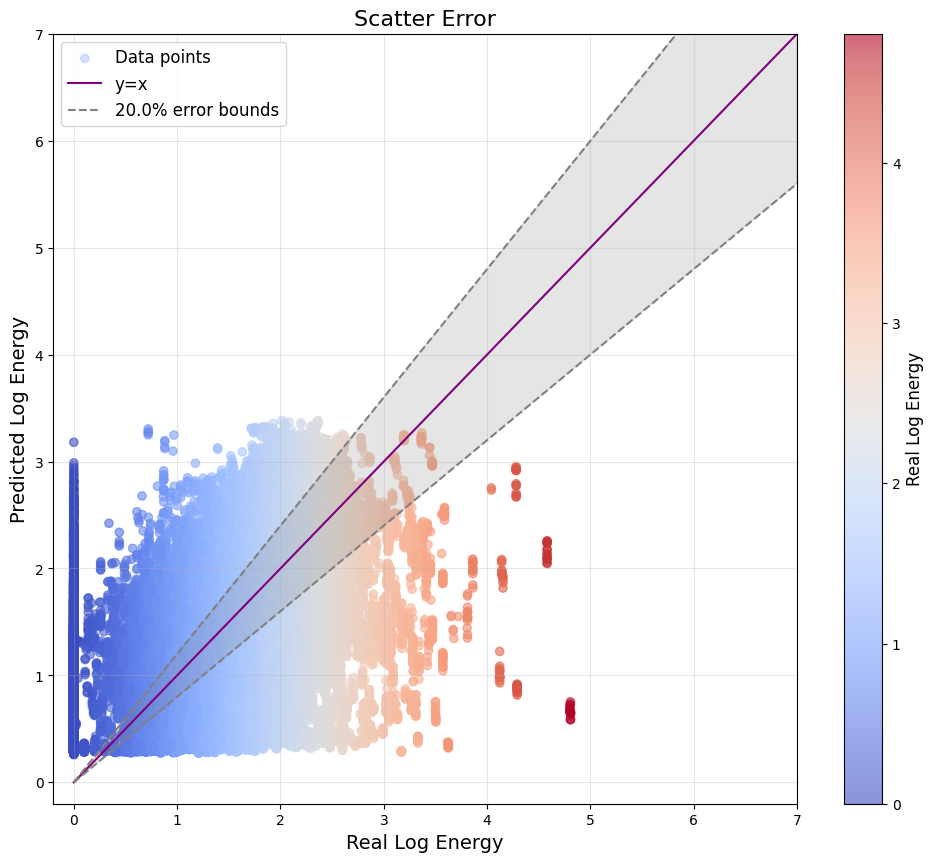

In [23]:
plot_error(energy_predict,earthquake_target,0.2)

In [24]:
energy_history_last = energy_history_all[:,-1,:,:].flatten().detach().cpu().numpy()

In [25]:
delta_energy_predict = energy_predict - energy_history_last
delta_energy_target = earthquake_target - energy_history_last

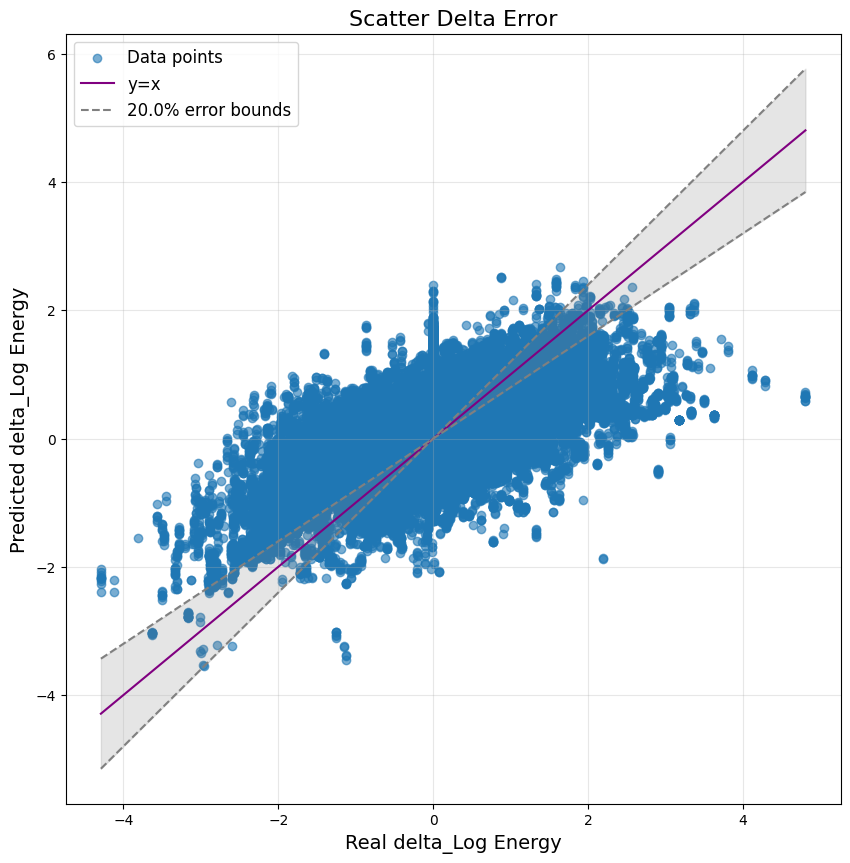

In [26]:
plot_delta_error(delta_energy_predict,delta_energy_target,0.2)

In [28]:
mse =np.power((energy_predict - earthquake_target),2).mean()
rmse = np.sqrt(mse)
nse = 1 - (np.sum(np.power((earthquake_target - energy_predict), 2)) / np.sum(np.power((earthquake_target - np.mean(earthquake_target)), 2)))
nnse = 1/(2-nse)
print("nnse:",nnse)
print('rmse:', rmse)
print('mse:', mse)

nnse: 0.5887168191355873
rmse: 0.7369902
mse: 0.5431546
